In [1]:
!hostname

node39.pri.prospero.alces.network


In [2]:
from swiftgalaxy import SWIFTGalaxy, SOAP, MaskCollection, SWIFTGalaxies
from scipy.spatial.transform import Rotation
from scipy.ndimage import rotate 
from swiftsimio.visualisation import project_gas, project_pixel_grid
import matplotlib.patches as patches
import sys
import warnings
import numpy as np, scipy, matplotlib.pyplot as plt, unyt as u, swiftsimio as sw, pandas as pd, glob, re
from scipy.spatial.transform import Rotation
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

project_root = #Path to project root here...s

if project_root not in sys.path:
    sys.path.append(project_root)


from modules.physics_utils import *

### Simulation Box Parameters

In [3]:
catalogue_file_path = #path to l025m5 catalogue z = 0 here 
snapshot_file_path = #path to l025m5 catalogue z = 0 here 

# 1. Candidates for high and low mass sample

These candidates will be used to plot a convergence test of anisotropy for differing inner radial cuts

In [4]:
sd = sw.load(catalogue_file_path)

In [5]:
# Define Mass Limits 
# 10^11.5 to 10^13.0 M_sun
low_limit = sw.cosmo_quantity(10**11.5, u.Msun, comoving=True, 
                              scale_factor=sd.metadata.a, scale_exponent=0)
mid_limit = sw.cosmo_quantity(10**12.0, u.Msun, comoving=True, 
                              scale_factor=sd.metadata.a, scale_exponent=0)
high_limit = sw.cosmo_quantity(10**13.0, u.Msun, comoving=True, 
                               scale_factor=sd.metadata.a, scale_exponent=0)

m200c = sd.spherical_overdensity_200_crit.total_mass

# Extract Indices for Low and High Mass Samples
idx_low = np.argwhere((m200c > low_limit) & (m200c < mid_limit)).squeeze()
idx_high = np.argwhere((m200c > mid_limit) & (m200c < high_limit)).squeeze()

print()

print(f'{len(idx_low)}  Lower mass Halos Found in given mass range')
print(f'{len(idx_high)}  Higher mass Halos Found in given mass range')
print(f'{len(m200c)} Halos in total')


49  Lower mass Halos Found in given mass range
19  Higher mass Halos Found in given mass range
1218083 Halos in total


In [6]:
sample_indices = np.concatenate([
    np.random.choice(idx_low, 5, replace=False),
    np.random.choice(idx_high, 5, replace=False)
])

### Re-defined masking in alignment function to check ideal inner radial cut

This takes the alignment and masking function and makes the inner radial cut changeable by a fraction (x) of R_200c. 

This is used to find an optimal fraction x to be used for all future analysis

The convergence test function for a halo of soap index 'idx', Loops over a range of inner radial cuts to test, for each inner radial cut initialise a swiftgalaxy type, mask and align according to the corresponding inner radial cut, and store the computed anisotropy parameter

In [7]:
def mask_edge_on_test(sg, x): 

   
    r = sg.gas.spherical_coordinates.r
    r200 = sg.halo_catalogue.spherical_overdensity_200_crit.soradius
    ang_mom_vec = sg.halo_catalogue.exclusive_sphere_10kpc.angular_momentum_stars

   

    group_nr = sg.gas.group_nr_bound
    mask = MaskCollection(
        #gas=sg.gas.spherical_coordinates.r < 50. * u.kpc, ##Change back to 50
        
        gas= (r > x*r200) & (r < r200) & ((group_nr == -1) | (group_nr == sg.halo_catalogue.input_halos.halo_catalogue_index))
        #gas=  (r < r200) & ((group_nr == -1) | (group_nr == sg.halo_catalogue.input_halos.halo_catalogue_index)) #(include disk)
        
        #gas= ((group_nr == -1) | (group_nr == sg.halo_catalogue.soap_index))
        #Will also utilise group_nr bound
    )

    sg.mask_particles(mask)

    # Define a new coordinate system from the angular momentum vector
    ang_mom_vec = ang_mom_vec.squeeze()

    zhat = (ang_mom_vec / np.sqrt(np.sum(ang_mom_vec**2))).to_value(u.dimensionless)  # we'll align L with the z-axis

    arb = np.ones(3) / np.sqrt(3)  # Take an arbitrary vector
    xvec = arb - arb.dot(zhat) * zhat # Make it orthogonal to zhat
    xhat = xvec / np.sqrt(np.sum(xvec**2)) # normalise it

    yhat = np.cross(zhat, xhat)  # Get the unit vector orthogonal to both xhat and zhat

   # rot_angle = np.pi/4
   # x = xhat * np.cos(rot_angle) - zhat * np.sin(rot_angle)
   # y = xhat * np.sin(rot_angle) + zhat * np.cos(rot_angle)
    #rotmat = np.vstack((x, y, yhat)).T
    #rotmat = np.vstack((-zhat, yhat, xhat)).T ##Edge-on upwards

    rotmat = np.vstack((xhat, -zhat, yhat)).T ##Edge-on sidewards
    
    sg.rotate(Rotation.from_matrix(rotmat))


def run_convergence_test(idx, radial_cuts):
    """
    Reruns the anisotropy calculation for a single galaxy across multiple cuts.
    """
    q_results = []
    
    for x in radial_cuts:
        

        sg_obj =  SWIFTGalaxy(snapshot_file_path, SOAP(catalogue_file_path, soap_index=idx, extra_mask=None))
        mask_edge_on_test(sg_obj, x) 
        
        # Check if CGM is empty after masking 
        if len(sg_obj.gas.coordinates) == 0:
            q_results.append(np.nan)
            continue
            
        # Project to 2D Image 
        img = sg_img(sg_obj)
        
        # Calculate Anisotropy Ratio q 
        q_val = pixel_anisotropy(img)
        q_results.append(q_val)
        
        

    return q_results

In [ ]:
convergence_data = {}
radial_space = np.linspace(0.01, 0.4, 20)
convergence_data['radial_space'] = radial_space


for halo_idx in sample_indices:
    print(f"Processing Halo {halo_idx}...")
    q_values = run_convergence_test(halo_idx, radial_space)
    convergence_data[f"halo_{halo_idx}"] = q_values


np.save('cgm_convergence_data.npy', convergence_data)


### 3. Convergence test results

There is a quite a bit of leeway here, Most haloes tend exhibit stable anisotropies over differing radii past 0.09R_200c. 

However one halo here has quite a large radius at which it becomes stable, most probably a larger disk. 

For safety, i opted to choose 0.25Rc, a nice number that gives plenty of headroom for the outliers 

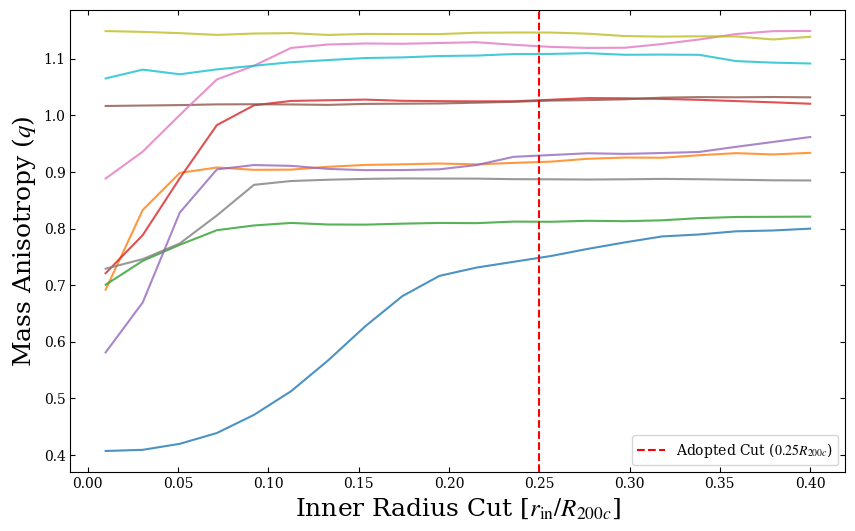

In [14]:
data = np.load('cgm_convergence_data.npy', allow_pickle=True).item()
radial_space = data['radial_space']

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

plt.figure(figsize=(10, 6), facecolor='white')
for key in data:
    if key != 'radial_space':
        plt.plot(radial_space, data[key], alpha=0.8)

plt.axvline(0.25, color='red', linestyle='--', label=r'Adopted Cut ($0.25 R_{200c}$)')
plt.ylabel('Mass Anisotropy ($q$)',fontsize=18)
plt.xlabel(r'Inner Radius Cut [$r_{\text{in}} / R_{200c}$]', fontsize=18)
plt.legend()
plt.show()